<a href="https://colab.research.google.com/github/Muhammad-Waleed-Source/Data-Analysis-Process/blob/main/EDA/EDA-Smartphones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

In [4]:
df = pd.read_csv('/content/smartphone_cleaned_v5.csv')
df.head()

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,battery_capacity,fast_charging_available,fast_charging,ram_capacity,internal_memory,screen_size,refresh_rate,resolution,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto
0,oneplus,OnePlus 11 5G,54999,89.0,True,True,False,snapdragon,8.0,3.2,5000.0,1,100.0,12.0,256.0,6.70,120,1440 x 3216,3,1.0,android,50.0,16.0,0,NaN
1,oneplus,OnePlus Nord CE 2 Lite 5G,19989,81.0,True,False,False,snapdragon,8.0,2.2,5000.0,1,33.0,6.0,128.0,6.59,120,1080 x 2412,3,1.0,android,64.0,16.0,1,1024.0
2,samsung,Samsung Galaxy A14 5G,16499,75.0,True,False,False,exynos,8.0,2.4,5000.0,1,15.0,4.0,64.0,6.60,90,1080 x 2408,3,1.0,android,50.0,13.0,1,1024.0
3,motorola,Motorola Moto G62 5G,14999,81.0,True,False,False,snapdragon,8.0,2.2,5000.0,1,NaN,6.0,128.0,6.55,120,1080 x 2400,3,1.0,android,50.0,16.0,1,1024.0
4,realme,Realme 10 Pro Plus,24999,82.0,True,False,False,dimensity,8.0,2.6,5000.0,1,67.0,6.0,128.0,6.70,120,1080 x 2412,3,1.0,android,108.0,16.0,0,NaN


In [5]:
df.shape

(980, 25)

In [7]:
df.info()

# some cols are floats because the contain NaN values, so we cannot convert them to integer

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand_name                 980 non-null    object 
 1   model                      980 non-null    object 
 2   price                      980 non-null    int64  
 3   rating                     879 non-null    float64
 4   has_5g                     980 non-null    bool   
 5   has_nfc                    980 non-null    bool   
 6   has_ir_blaster             980 non-null    bool   
 7   processor_brand            960 non-null    object 
 8   num_cores                  974 non-null    float64
 9   processor_speed            938 non-null    float64
 10  battery_capacity           969 non-null    float64
 11  fast_charging_available    980 non-null    int64  
 12  fast_charging              769 non-null    float64
 13  ram_capacity               980 non-null    float64

### Why to do EDA?

- For a blog
- For a ML model to predict price based on specifications (Doing this)
- To decide the startegy to fill the missing values

In [8]:
df.isnull().sum()

,0
brand_name,0
model,0
price,0
rating,101
has_5g,0
has_nfc,0
has_ir_blaster,0
processor_brand,20
num_cores,6
processor_speed,42


## brand_name

In [9]:
df['brand_name'].value_counts()

,count
brand_name,
xiaomi,134
samsung,132
vivo,111
realme,97
oppo,88
motorola,52
apple,46
oneplus,42
poco,41


<Axes: xlabel='brand_name'>

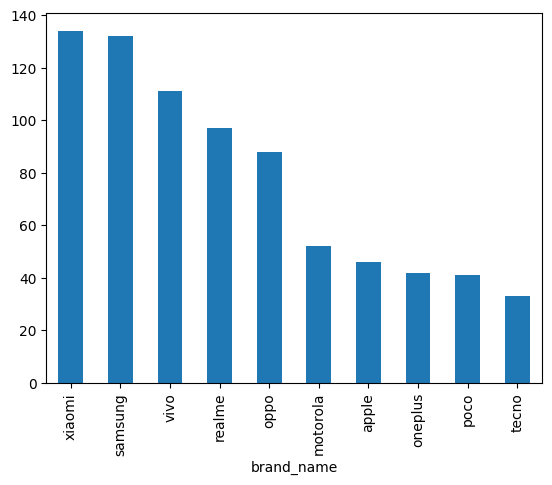

In [11]:
# plotting a graph for top ten brands
df['brand_name'].value_counts().head(10).plot(kind='bar')

<Axes: ylabel='count'>

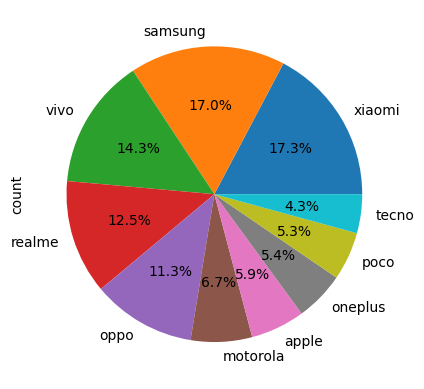

In [12]:
# percentage share of market

df['brand_name'].value_counts().head(10).plot(kind='pie', autopct='%0.1f%%')

In [13]:
df['brand_name'].isnull().sum()

# no missing values

np.int64(0)

## model

In [14]:
# it is not a categorical nor numerical col so we cannot do any type of analysis

df['model'].nunique()

# every phone is different from other

980

## price

- The distribution is not normal because mean and median(50%) daviates (skewed)
- There are outliers in the data

In [15]:
df['price'].describe()

,price
count,980.000000
mean,32520.504082
std,39531.812669
min,3499.000000
25%,12999.000000
50%,19994.500000
75%,35491.500000
max,650000.000000


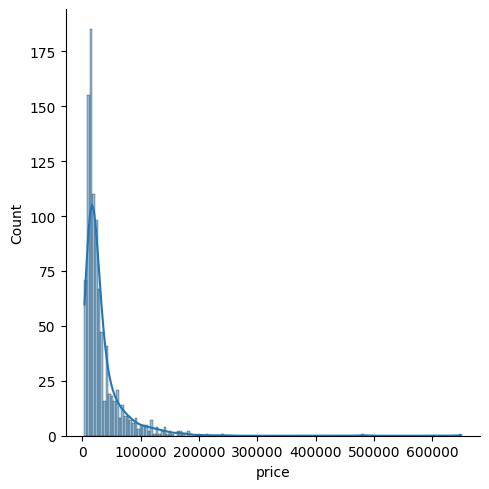

In [17]:
sns.displot(kind='hist', data=df, x='price', kde=True)

# highly skewed, there are maximum number of phone in range of 50k

In [19]:
print(df['price'].skew())

# not normally distributed

6.591790999665567


<Axes: ylabel='price'>

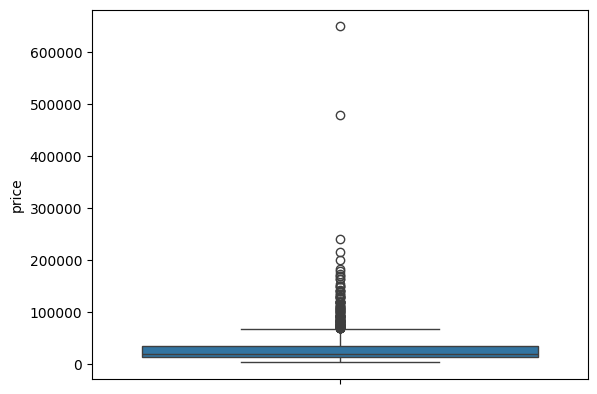

In [20]:
sns.boxplot(df['price'])

In [21]:
# checking those outliers

df[df['price'] > 200000]

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,battery_capacity,fast_charging_available,fast_charging,ram_capacity,internal_memory,screen_size,refresh_rate,resolution,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto
427,vertu,Vertu Signature Touch,650000,62.0,False,True,False,snapdragon,8.0,1.50,2275.0,0,NaN,2.0,64.0,4.70,60,1080 x 1920,1,1.0,android,13.0,2.1,0,NaN
478,huawei,Huawei Mate 50 RS Porsche Design,239999,81.0,False,True,True,snapdragon,8.0,3.20,4700.0,1,66.0,12.0,512.0,6.74,120,1212 x 2616,3,1.0,other,50.0,13.0,1,256.0
887,xiaomi,Xiaomi Redmi K20 Pro Signature Edition,480000,88.0,False,True,False,snapdragon,8.0,2.80,4000.0,1,27.0,8.0,256.0,6.39,60,1080 x 2340,3,1.0,android,48.0,20.0,0,NaN
951,huawei,Huawei Mate 30 RS Porsche Design,214990,NaN,True,True,True,kirin,8.0,2.86,4500.0,1,NaN,12.0,512.0,6.53,60,1176 x 2400,4,2.0,android,40.0,32.0,1,256.0


- We will remove these outliers because they represent luxury editions of phones. Although they have specifications similar to other models, their prices are significantly higher due to premium materials such as gold and diamonds rather than better hardware.

- Since our goal is to predict a phone's price based on its specifications, these luxury phones do not represent the general pricing pattern and could negatively affect the model. Therefore, they are not relevant for our analysis and will be removed.


In [22]:
df['price'].isnull().sum()

np.int64(0)

## rating

In [23]:
df['rating'].describe()

,rating
count,879.000000
mean,78.258248
std,7.402854
min,60.000000
25%,74.000000
50%,80.000000
75%,84.000000
max,89.000000


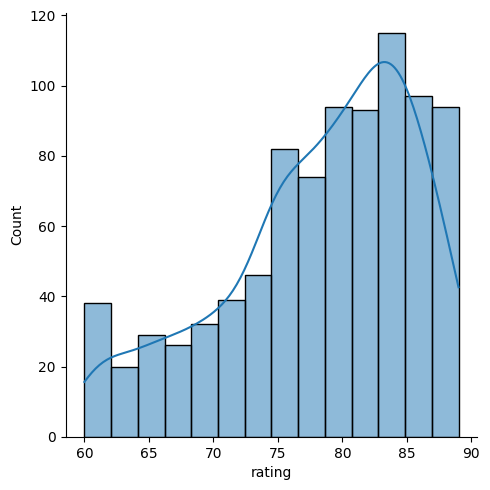

In [24]:
sns.displot(kind='hist', data=df, x='rating', kde=True)

# a little skewed

In [25]:
df['rating'].skew()

# close to 0, so it is a good sign

np.float64(-0.6989993034105535)

<Axes: ylabel='rating'>

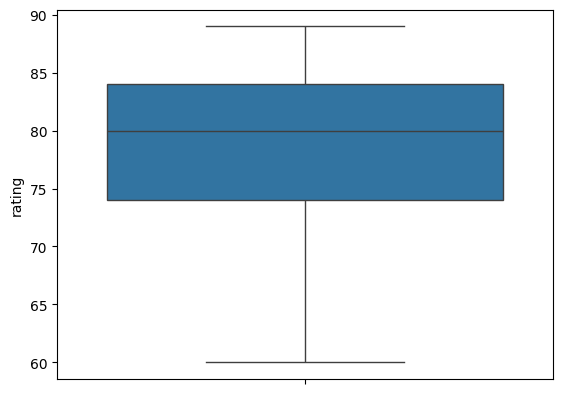

In [30]:
sns.boxplot(df['rating'])

# no outliers

In [31]:
print(df['rating'].isnull().sum())

np.int64(101)

In [32]:
print((df['rating'].isnull().sum() / 980)*100)

# 10% missing values

10.306122448979592


## has_5g

<Axes: ylabel='count'>

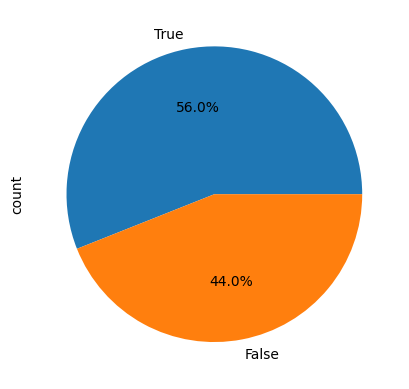

In [33]:
df['has_5g'].value_counts().plot(kind='pie', autopct='%0.1f%%')

## has_nfc

<Axes: ylabel='count'>

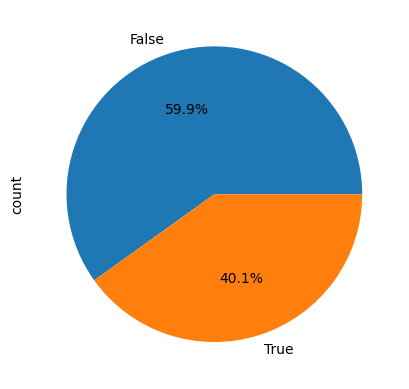

In [34]:
df['has_nfc'].value_counts().plot(kind='pie', autopct='%0.1f%%')

## has_ir_blaster

<Axes: ylabel='count'>

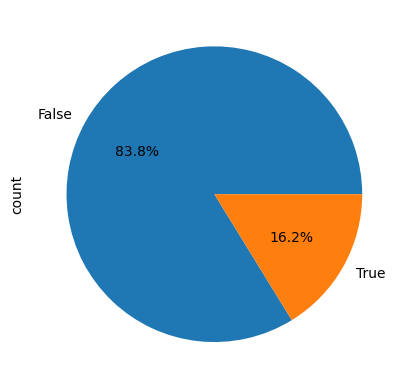

In [35]:
df['has_ir_blaster'].value_counts().plot(kind='pie', autopct='%0.1f%%')

In [38]:
df[df['has_ir_blaster'] == True]['brand_name'].value_counts()

,count
brand_name,
xiaomi,109
poco,30
iqoo,6
huawei,6
vivo,4
redmi,2
honor,1
samsung,1
